# Training — Variational Autoencoder (VAE)

<div style="text-align: justify">

The following notebook trains a <b>Variational Autoencoder (VAE)</b> for the <b>Tau Anomaly Detection</b> analysis. The model is trained on <b>background-only</b> events using PyTorch Lightning. Signal events are held out and used only to visualise reconstruction error separation after training. In addition to reconstruction diagnostics, this notebook includes <b>VAE-specific latent space analysis</b> and <b>KL divergence monitoring</b> for posterior collapse detection. Experiment metrics are tracked with <b>Weights & Biases</b>.

</div>

## Pipeline Summary

| Step | Module | Description |
|------|--------|-------------|
| Config | `hydra.compose` | Load analysis and model configuration |
| DataModule | `datamodule.AnomalyDataModule` | Read mc.parquet, split bkg/sig, fit scaler, build dataloaders |
| Model | `vae.VariationalAutoencoder` | Instantiate VAE with reparameterization trick |
| Logger | `WandbLogger` | Initialise Weights & Biases experiment tracking |
| Train | `lightning.Trainer` | Fit model with early stopping and checkpointing |
| Scores | `anomaly.reconstruction_error` | Compute per-event anomaly scores on predict set |
| Diagnostics | `plots` | Loss components, reconstruction error, latent space analysis |

The same pipeline is available as a CLI via `uv run python run.py stage=train model=vae`.

## Initialization

### Libraries

Configuration:
* [Hydra](https://hydra.cc/)
* [OmegaConf](https://omegaconf.readthedocs.io/)
* [pyrootutils](https://github.com/ashleve/pyrootutils)

Data Processing:
* [Pandas](https://pandas.pydata.org/)

Machine Learning:
* [PyTorch](https://pytorch.org/)
* [PyTorch Lightning](https://lightning.ai/docs/pytorch/stable/)

Experiment Tracking:
* [Weights & Biases](https://wandb.ai/)

### Notebook

Activating autoreload of imported modules.

In [1]:
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = "retina"

Initializing the project root.

In [2]:
import pyrootutils

path = pyrootutils.setup_root(
    search_from=__file__ if "__file__" in locals() else ".",
    indicator=".gitignore",
    pythonpath=True,
)

Suppressing unessential warnings and applying ATLAS style.

In [3]:
from src.utils import suppress_warnings
from src.visualization.plots import apply_atlas_style

suppress_warnings()
apply_atlas_style()

## Configuration

Loading the Hydra configuration with the VAE model config.

In [4]:
from hydra import compose, initialize_config_dir

initialize_config_dir(config_dir=str(path / "configs"), version_base="1.3")
cfg = compose(config_name="config", overrides=["model=vae"])

Resolving input and output directories from config.

In [5]:
from src.processing.analysis import get_output_paths

output_paths = get_output_paths(cfg)
dataframes_dir = path / output_paths["dataframes_dir"]
models_dir = path / output_paths["models_dir"]
plots_dir = path / output_paths["plots_dir"] / "vae"

models_dir.mkdir(parents=True, exist_ok=True)
plots_dir.mkdir(parents=True, exist_ok=True)

## DataModule

Setting up the `AnomalyDataModule`. It reads the MC parquet, separates background from signal, fits a scaler on the background training split, and builds `TensorDataset` objects that pair features with event weights.

In [6]:
import lightning as L

L.seed_everything(cfg.seed, workers=True)

Seed set to 1


1

In [7]:
from src.models.datamodule import AnomalyDataModule

background_origins = {
    s["id"]
    for s in cfg.samples.background.samples
    if s["id"] not in set(cfg.samples.background.get("exclude", []))
}
print(f"Background origins: {background_origins}")

dm = AnomalyDataModule(
    mc_path=str(dataframes_dir / "mc.parquet"),
    background_origins=background_origins,
    normalization=cfg.model.normalization,
    val_fraction=cfg.pipeline.val_fraction,
    batch_size=cfg.model.batch_size,
    seed=cfg.seed,
)
dm.setup()
print(f"Features: {dm.n_features}")
print(f"Feature names: {dm.feature_names_}")

Background origins: {'singletop', 'ztautau', 'wenu', 'diboson', 'ttbar', 'ttX', 'znunu', 'wmunu', 'zmumu', 'wtaunu', 'zee'}
Features: 53
Feature names: ['nVtx', 'LeptonVeto', 'jet_n', 'jet_n_btag', 'sumMTJet', 'sumMTTauJet', 'met', 'met_phi', 'METSig', 'meff', 'ht', 'ele_n', 'mu_n', 'Mt2_taumu', 'Mt2_tauel', 'Mtaumu', 'Mtauel', 'tau_pt_0', 'tau_eta_0', 'tau_phi_0', 'tau_charge_0', 'tau_ntracks_0', 'tau_nIsolatedTracks_0', 'tau_nAllTracks_0', 'tau_width_0', 'tau_jetpt_0', 'tau_delPhiMet_0', 'tau_mtMet_0', 'tau_NNDecayMode_0', 'jet_pt_0', 'jet_pt_1', 'jet_pt_2', 'jet_eta_0', 'jet_eta_1', 'jet_eta_2', 'jet_phi_0', 'jet_phi_1', 'jet_phi_2', 'jet_mtMet_0', 'jet_mtMet_1', 'jet_mtMet_2', 'jet_isBjet_0', 'jet_isBjet_1', 'jet_isBjet_2', 'jet_jvt_0', 'jet_jvt_1', 'jet_jvt_2', 'jet_delPhiMet_0', 'jet_delPhiMet_1', 'jet_delPhiMet_2', 'jet_width_0', 'jet_width_1', 'jet_width_2']


## Model

Instantiating the Variational Autoencoder from the typed config. The encoder outputs `mu` and `logvar` for the latent distribution; the decoder reconstructs from samples drawn via the reparameterization trick.

In [8]:
from omegaconf import OmegaConf

from src.models.config import VAEConfig
from src.models.vae import VariationalAutoencoder

model_params = dict(OmegaConf.to_container(cfg.model, resolve=True))
model_cfg = VAEConfig(**model_params)
model = VariationalAutoencoder(model_cfg, n_features=dm.n_features)

n_params = sum(p.numel() for p in model.parameters())
print(f"VAE: {n_params:,} parameters")
print(f"Beta: {model_cfg.beta}, schedule: {model_cfg.beta_schedule}")
print(model)

VAE: 330,325 parameters
Beta: 0.0002, schedule: constant
VariationalAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=53, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
  )
  (fc_mu): Linear(in_features=256, out_features=16, bias=True)
  (fc_logvar): Linear(in_features=256, out_features=16, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=256, out_features=512, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=512, out_features=53, bias=True)
  )
  (recon_loss_fn): MSELoss()
)


## Training

### WandB Logger

Initialising the Weights & Biases logger. Set `enabled: false` in `configs/pipeline/default.yaml` to disable tracking.

In [9]:
from lightning.pytorch.loggers import WandbLogger

wandb_cfg = cfg.pipeline.wandb
if wandb_cfg.enabled:
    wandb_logger = WandbLogger(
        project=wandb_cfg.project,
        name=f"{cfg.experiment_name}-vae",
        log_model=wandb_cfg.log_model,
        config=dict(OmegaConf.to_container(cfg.model, resolve=True)),
    )
else:
    wandb_logger = False

print(f"WandB logging: {'enabled' if wandb_cfg.enabled else 'disabled'}")

WandB logging: enabled


### Trainer

Creating the Lightning Trainer with early stopping and model checkpointing.

In [10]:
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint

from src.models.callbacks import EpochProgressBar, MetricTracker

tracker = MetricTracker()

callbacks = [
    EarlyStopping(
        monitor=cfg.pipeline.monitor_metric,
        mode=cfg.pipeline.monitor_mode,
        patience=cfg.pipeline.early_stopping_patience,
        verbose=False,
    ),
    ModelCheckpoint(
        dirpath=models_dir,
        filename="vae-best",
        monitor=cfg.pipeline.monitor_metric,
        mode=cfg.pipeline.monitor_mode,
        save_top_k=1,
        verbose=False,
    ),
    EpochProgressBar(),
    tracker,
]

trainer = L.Trainer(
    max_epochs=cfg.model.n_epochs,
    callbacks=callbacks,
    logger=wandb_logger,
    deterministic=True,
    precision="16-mixed" if cfg.model.amp else "32-true",
    enable_progress_bar=False,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


### Fit

Training the VAE on background-only data. The VAE logs additional metrics: `recon_loss`, `kl_loss`, `beta`, `mu_mean`, `mu_var`, and `logvar_mean` for collapse monitoring.

In [11]:
trainer.fit(model, datamodule=dm)

wandb: WARNING The anonymous setting has no effect and will be removed in a future version.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [2]

  | Name          | Type       | Params | Mode  | FLOPs
-------------------------------------------------------------
0 | encoder       | Sequential | 158 K  | train | 0    
1 | fc_mu         | Linear     | 4.1 K  | train | 0    
2 | fc_logvar     | Linear     | 4.1 K  | train | 0    
3 | decoder       | Sequential | 163 K  | train | 0    
4 | recon_loss_fn | MSELoss    | 0      | train | 0    
-------------------------------------------------------------
330 K     Trainable params
0         Non-trainable params
330 K     Total params
1.321     Total estimated model params size (MB)
18        Modules in train mode
0         Modules in eval mode
0         Total Flops


Training:   0%|          | 0/10 [00:00<?, ?epoch/s]

`Trainer.fit` stopped: `max_epochs=10` reached.


### Checkpoint

Saving the final checkpoint (includes scaler state from the DataModule).

In [13]:
from pathlib import Path

best_path = getattr(trainer.checkpoint_callback, "best_model_path", None)
if best_path:
    best_path = Path(best_path).relative_to(path)
print(f"Best checkpoint: {best_path}")

ckpt_path = models_dir / "vae.ckpt"
trainer.save_checkpoint(ckpt_path)
print(f"Saved checkpoint: {ckpt_path.relative_to(path)}")

`weights_only` was not set, defaulting to `False`.


Best checkpoint: data/processed/ML/25.2.28/Run2/Preselection/1_tau/models/vae-best-v3.ckpt
Saved checkpoint: data/processed/ML/25.2.28/Run2/Preselection/1_tau/models/vae.ckpt


## Diagnostics

### Loss Curves

Plotting train and validation loss over epochs, plus VAE-specific loss components (reconstruction, KL, beta).

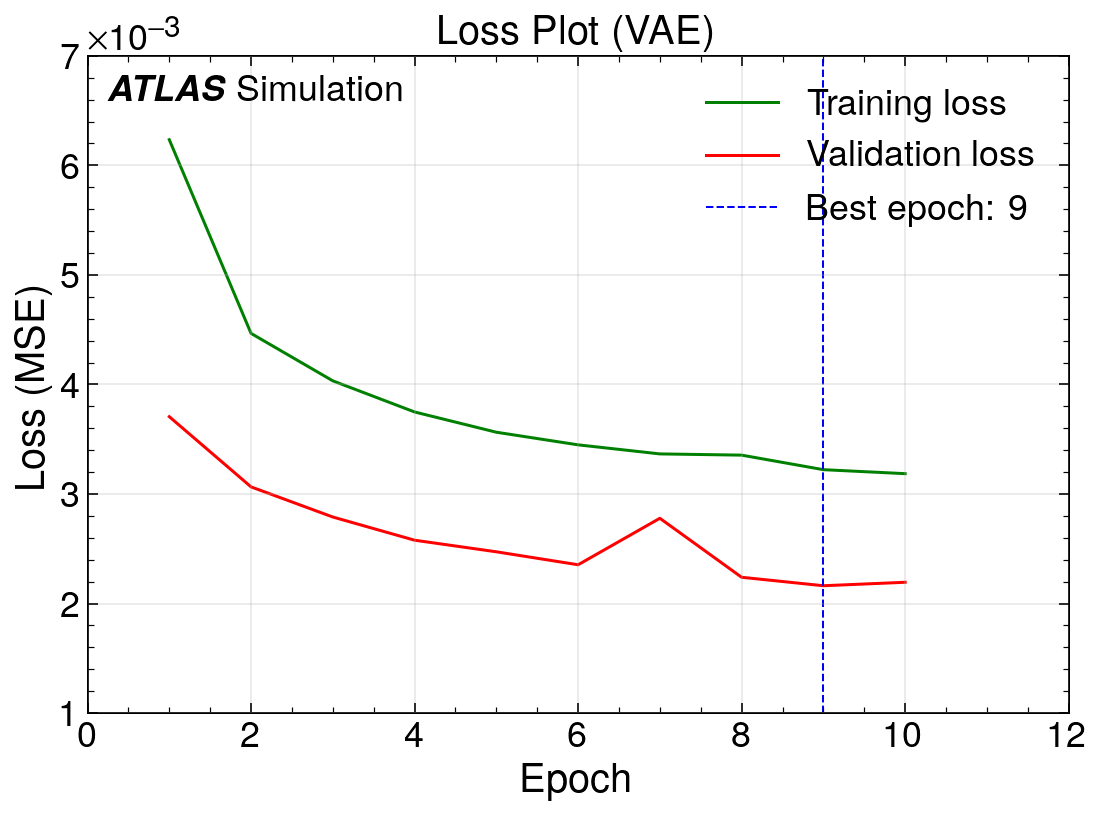

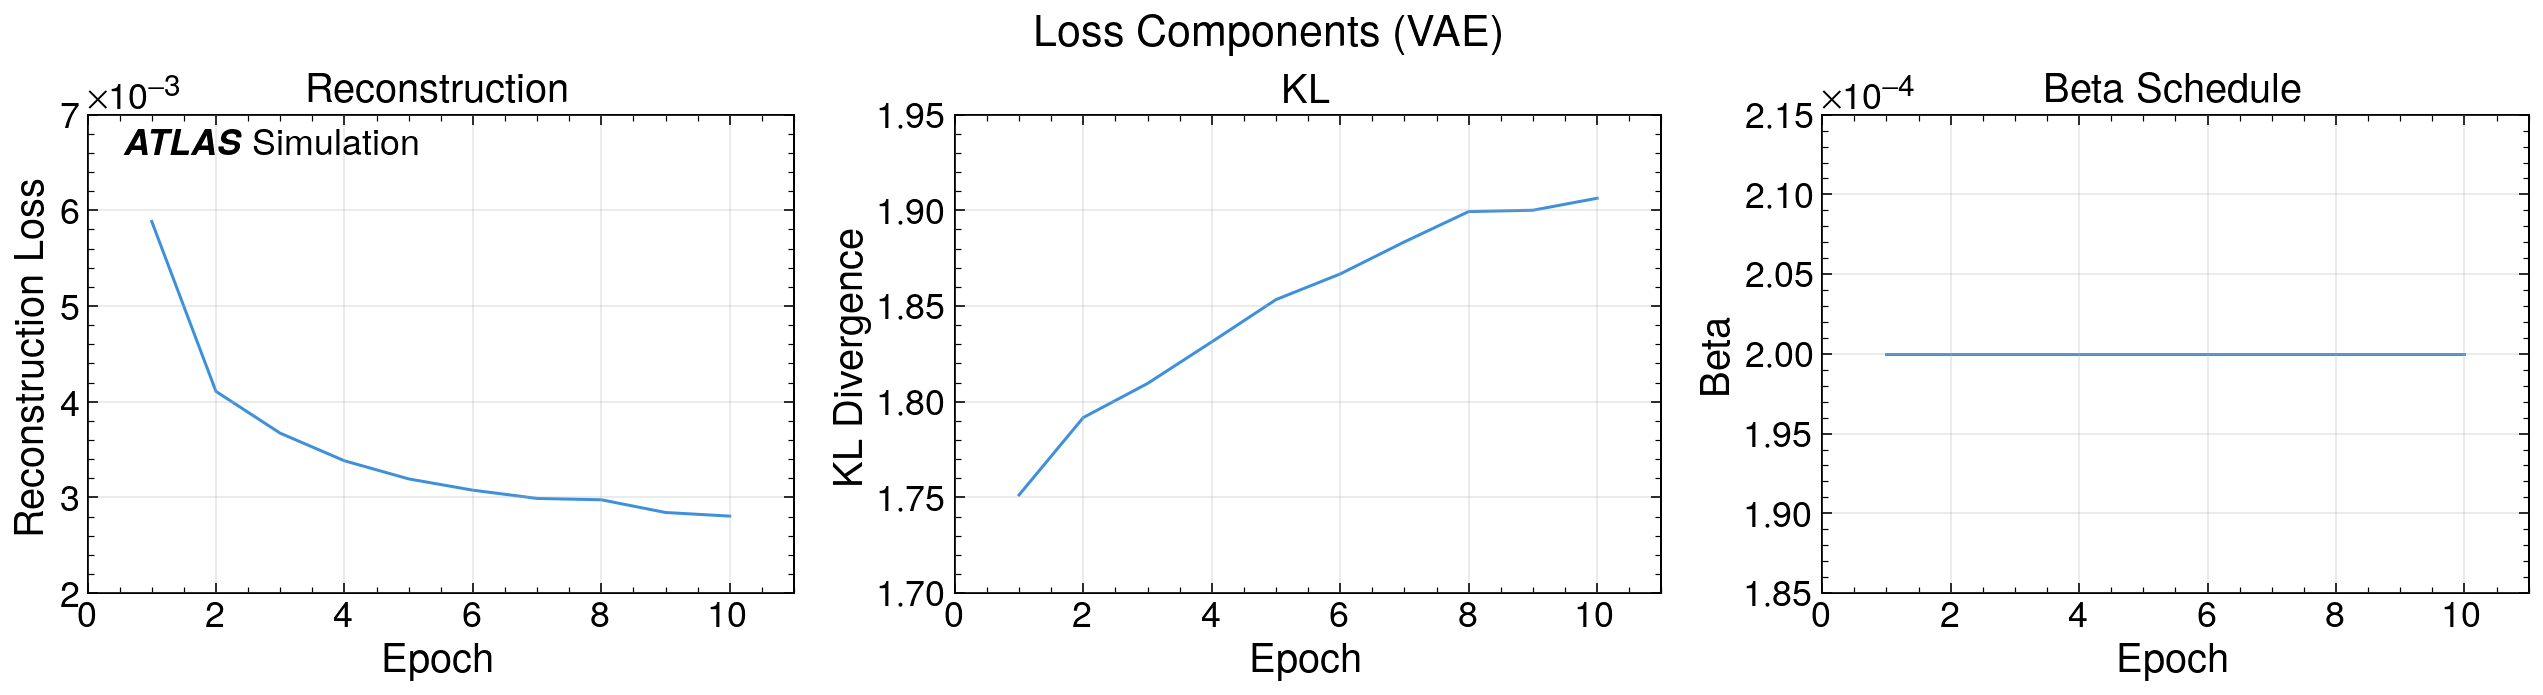

In [16]:
from src.models.plots import plot_loss, plot_loss_components

fig = plot_loss(tracker.history["train_loss"], tracker.history["val_loss"], title="Loss Plot (VAE)")
fig.savefig(plots_dir / "vae_loss.png")

fig = plot_loss_components(
    tracker.history["train_recon_loss"],
    tracker.history["train_kl_loss"],
    beta_values=tracker.history.get("train_beta"),
    title="Loss Components (VAE)",
)
fig.savefig(plots_dir / "vae_loss_components.png")

### Anomaly Scores

Computing reconstruction error on the predict set (background validation + signal). Higher reconstruction error indicates a more anomalous event.

In [17]:
import torch
import numpy as np

from src.models.anomaly import reconstruction_error, compute_threshold, build_scores_frame

predictions = trainer.predict(model, datamodule=dm)
x_hat = torch.cat(predictions)
x_orig = torch.cat([batch[0] for batch in dm.predict_dataloader()])

scores = reconstruction_error(x_orig, x_hat).numpy()
print(f"Scores: {len(scores):,} events")
print(f"  Background mean: {scores[dm.predict_labels == 0].mean():.6f}")
print(f"  Signal mean:     {scores[dm.predict_labels == 1].mean():.6f}")

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [2]


Scores: 5,124,922 events
  Background mean: 0.095034
  Signal mean:     0.302432


### Threshold

In [18]:
bkg_scores = scores[dm.predict_labels == 0]
sig_scores = scores[dm.predict_labels == 1]

threshold = compute_threshold(
    bkg_scores,
    strategy=cfg.pipeline.threshold_strategy,
    percentile=cfg.pipeline.threshold_percentile,
)
print(f"Threshold ({cfg.pipeline.threshold_strategy}): {threshold:.6f}")
print(f"  Background flagged: {(bkg_scores > threshold).sum():,} / {len(bkg_scores):,}")
print(f"  Signal flagged:     {(sig_scores > threshold).sum():,} / {len(sig_scores):,}")

Threshold (percentile): 0.260957
  Background flagged: 58,779 / 1,175,562
  Signal flagged:     1,272,145 / 3,949,360


### Reconstruction Error Distribution

Comparing the reconstruction error distributions of background and signal events.

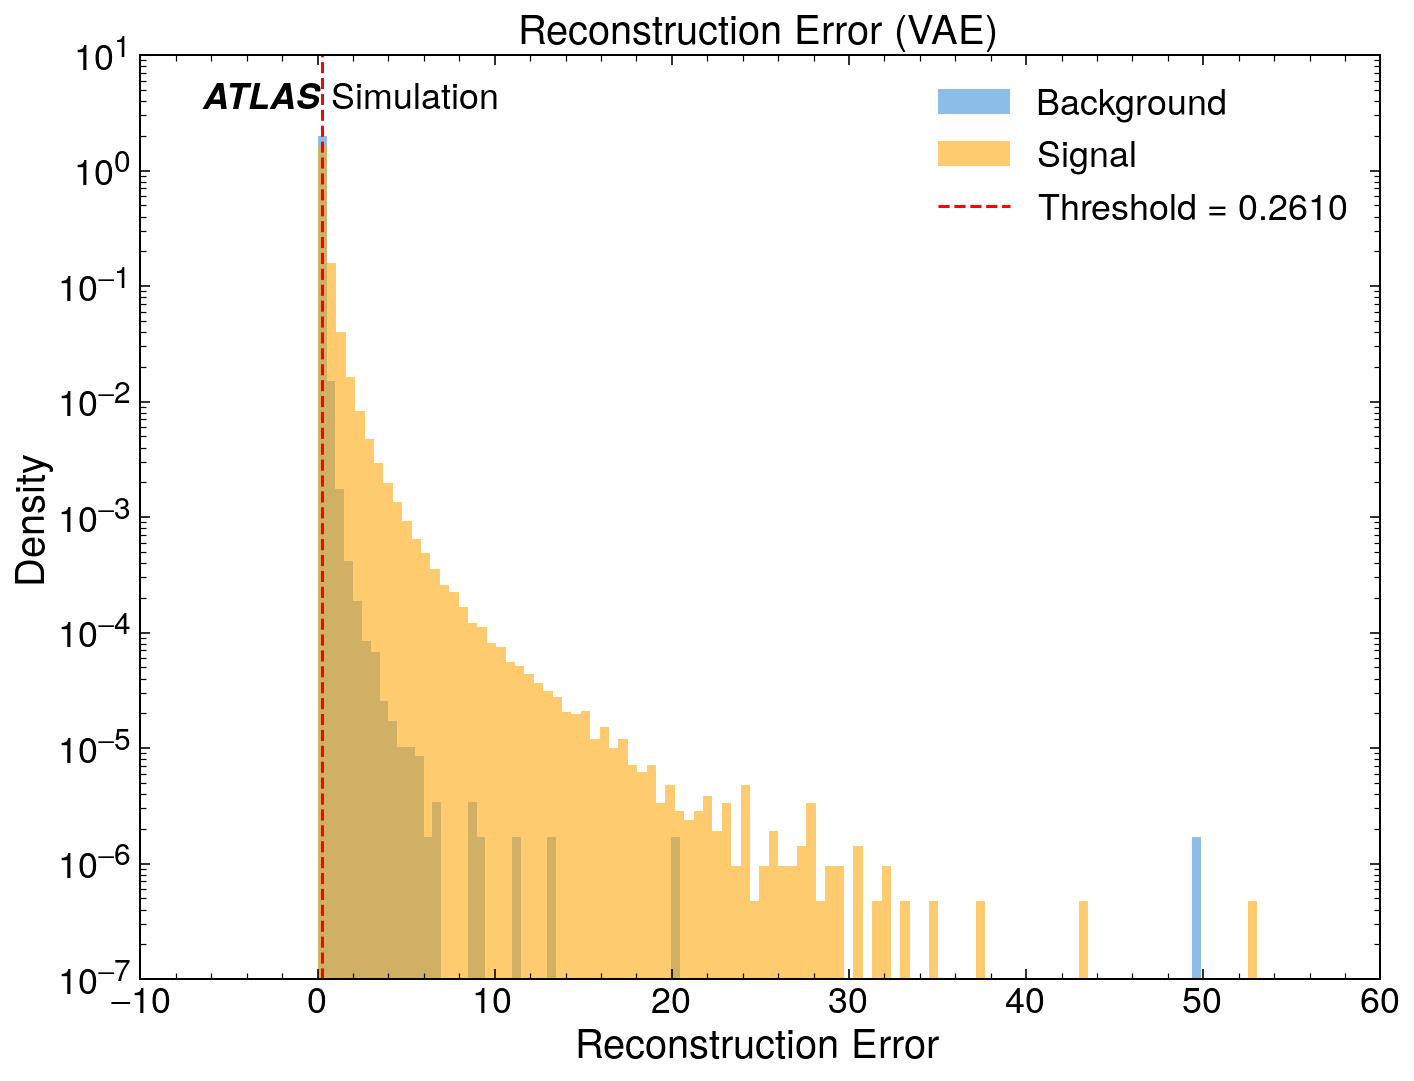

In [19]:
from src.models.plots import plot_reconstruction_error

fig = plot_reconstruction_error(bkg_scores, sig_scores, threshold=threshold, title="Reconstruction Error (VAE)")
fig.savefig(plots_dir / "vae_reconstruction_error.png")

### Single Event Reconstruction

Bar chart comparing original vs reconstructed feature values for a single event.

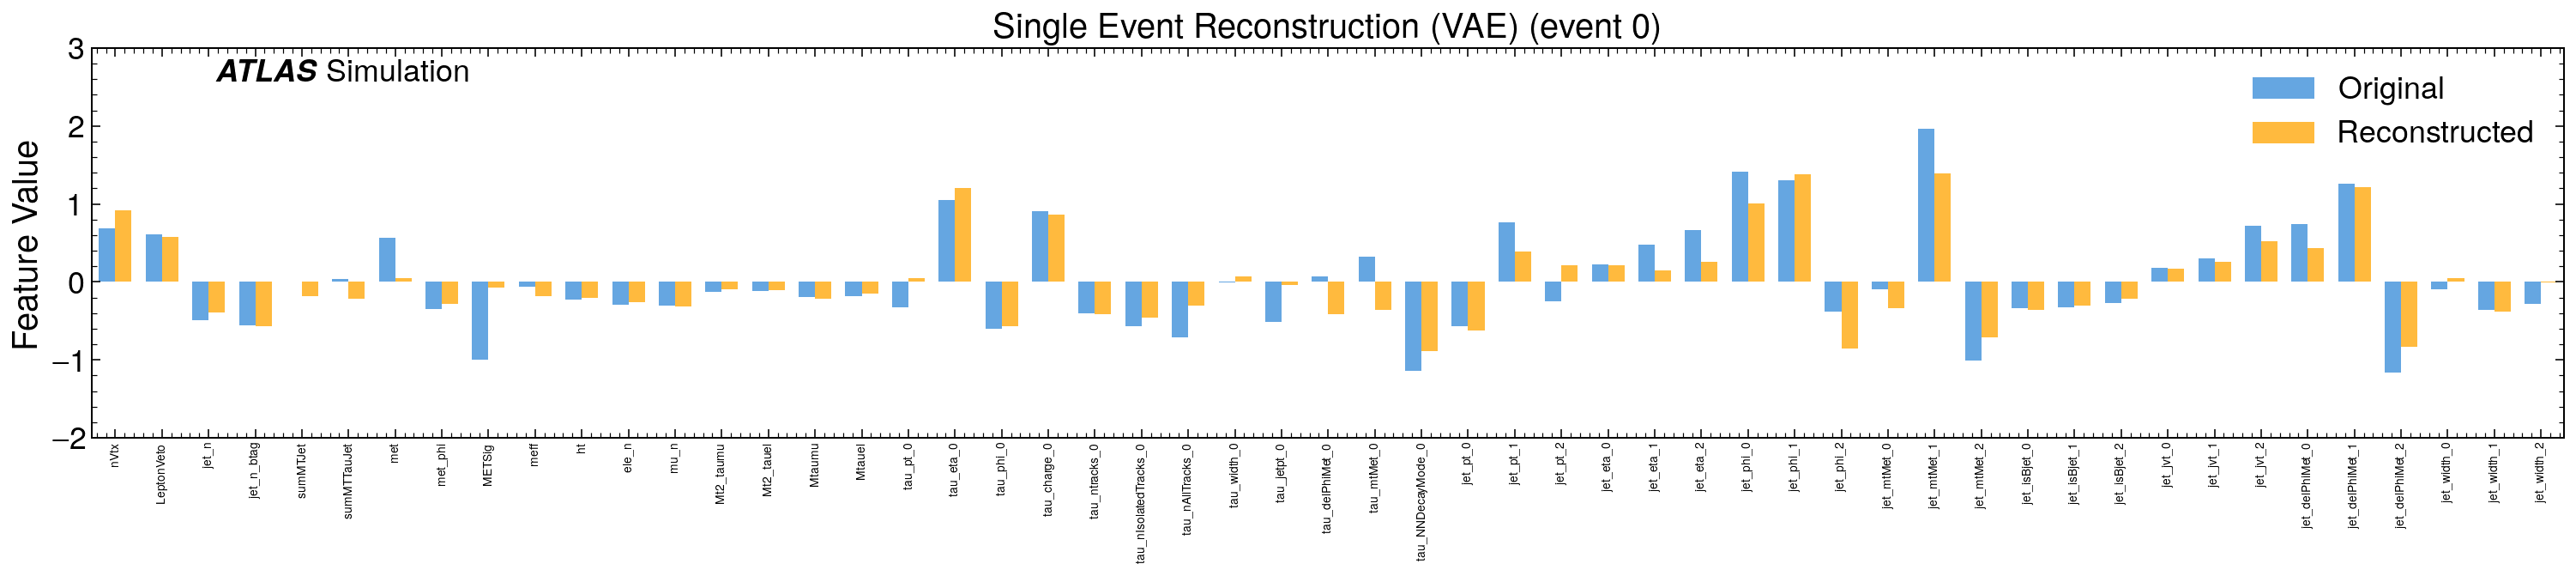

In [20]:
from src.models.plots import plot_reconstruction_performance

fig = plot_reconstruction_performance(
    x_orig[0].numpy(),
    x_hat[0].numpy(),
    dm.feature_names_,
    event_idx=0,
    title="Single Event Reconstruction (VAE)",
)
fig.savefig(plots_dir / "vae_single_event.png")

### Feature Histograms

Per-feature distributions of original vs reconstructed values across the predict set.

In [21]:
from src.models.plots import plot_feature_histograms

fig = plot_feature_histograms(
    x_orig.numpy(),
    x_hat.numpy(),
    dm.feature_names_,
    title="Feature Distributions (VAE)",
)
fig.savefig(plots_dir / "vae_feature_histograms.png")

## Latent Space Analysis

Encoding the predict set to extract `mu` and `logvar` for latent diagnostics.

In [22]:
model.eval()
all_mu, all_logvar = [], []
with torch.no_grad():
    for batch in dm.predict_dataloader():
        x, _w = batch
        mu, logvar = model.encode(x)
        all_mu.append(mu)
        all_logvar.append(logvar)

mu_np = torch.cat(all_mu).numpy()
logvar_np = torch.cat(all_logvar).numpy()
print(f"Latent space: {mu_np.shape[0]:,} events, {mu_np.shape[1]} dimensions")

Latent space: 5,124,922 events, 16 dimensions


### Latent Mean Spread

Variance of `mu` per latent dimension. Dimensions with variance below 0.1 indicate potential posterior collapse.

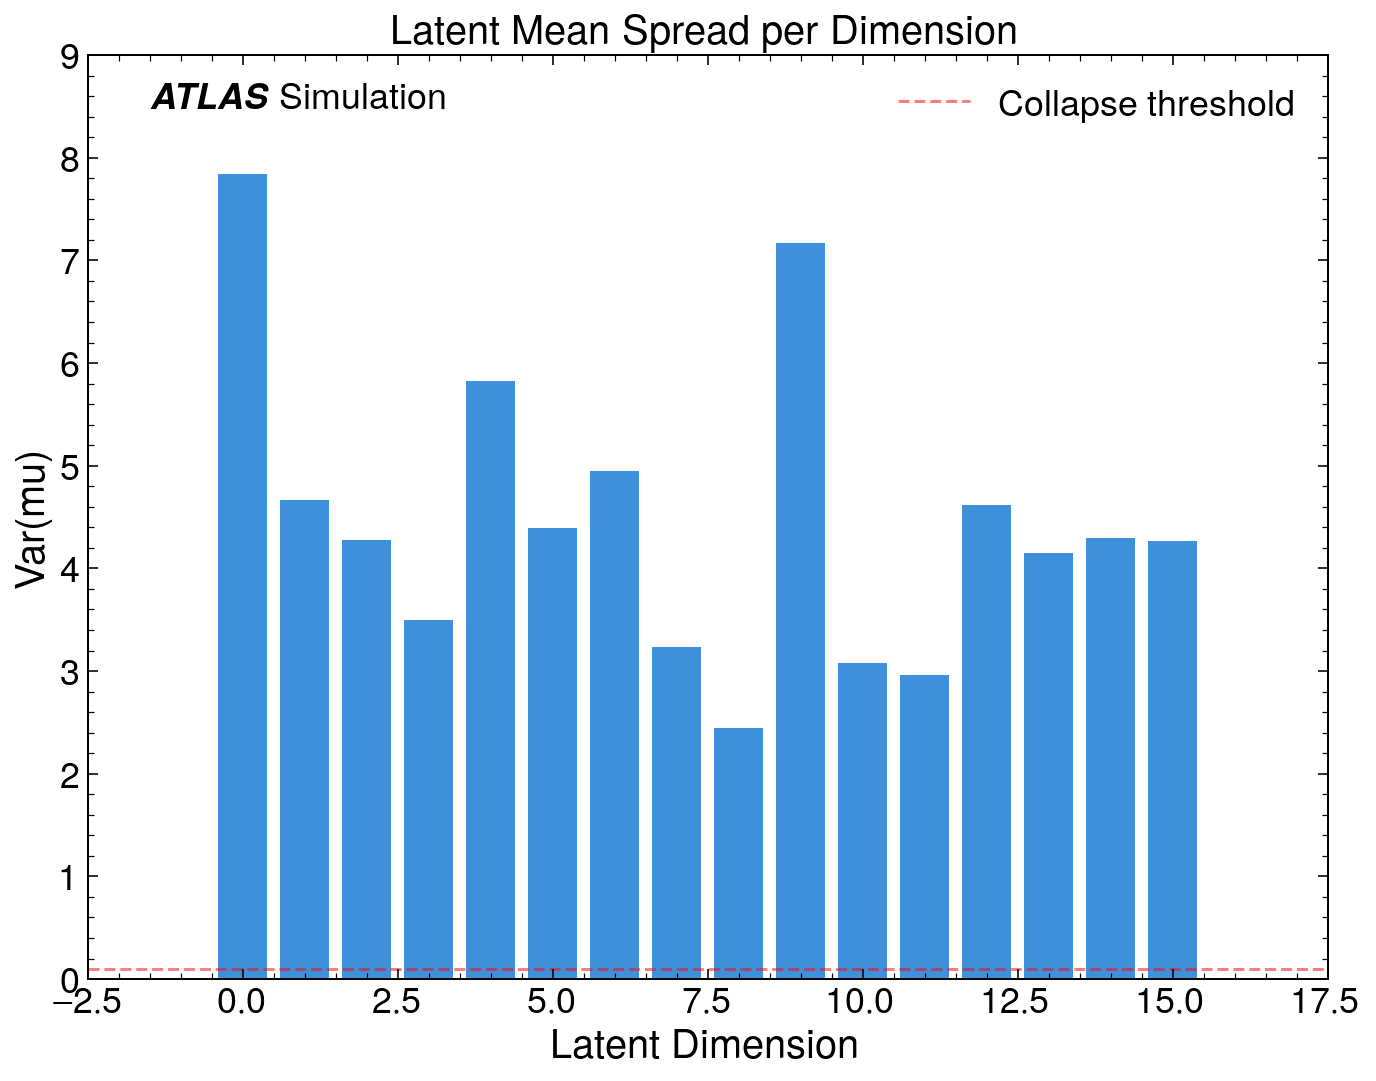

In [23]:
from src.models.plots import plot_latent_mean_spread

fig = plot_latent_mean_spread(mu_np)
fig.savefig(plots_dir / "vae_mu_spread.png")

### Log-Variance Spread

Mean `logvar` per latent dimension. Dimensions with mean logvar below -5 indicate potential collapse.

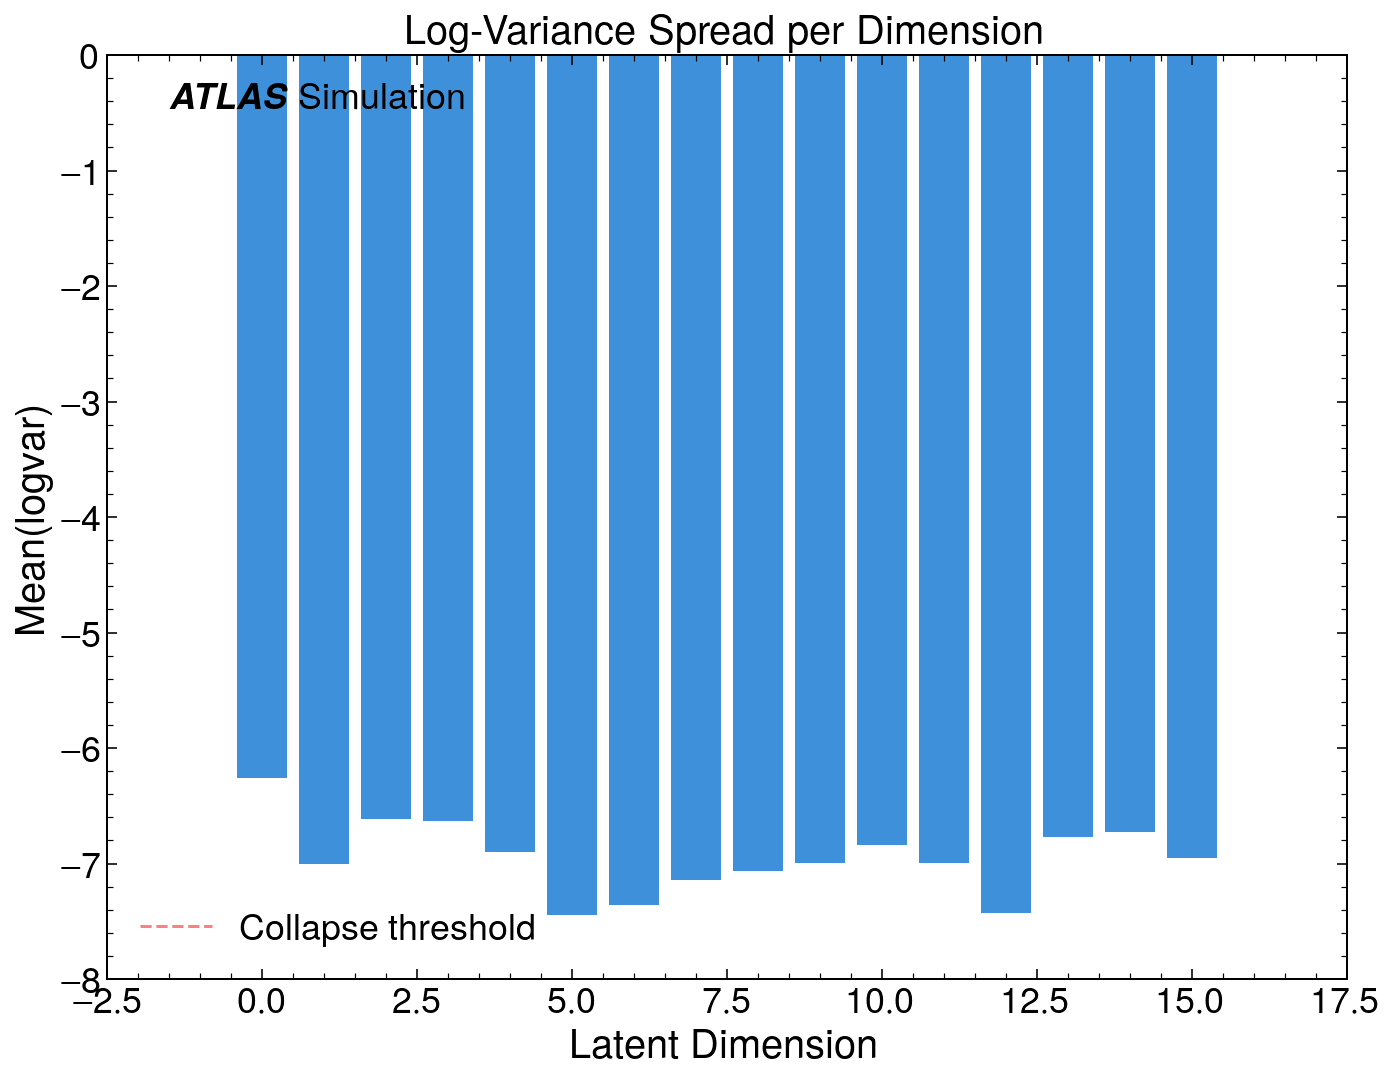

In [24]:
from src.models.plots import plot_logvar_spread

fig = plot_logvar_spread(logvar_np)
fig.savefig(plots_dir / "vae_logvar_spread.png")

### Mu vs Logvar

Scatter plot of mean `mu` vs mean `logvar` per latent dimension.

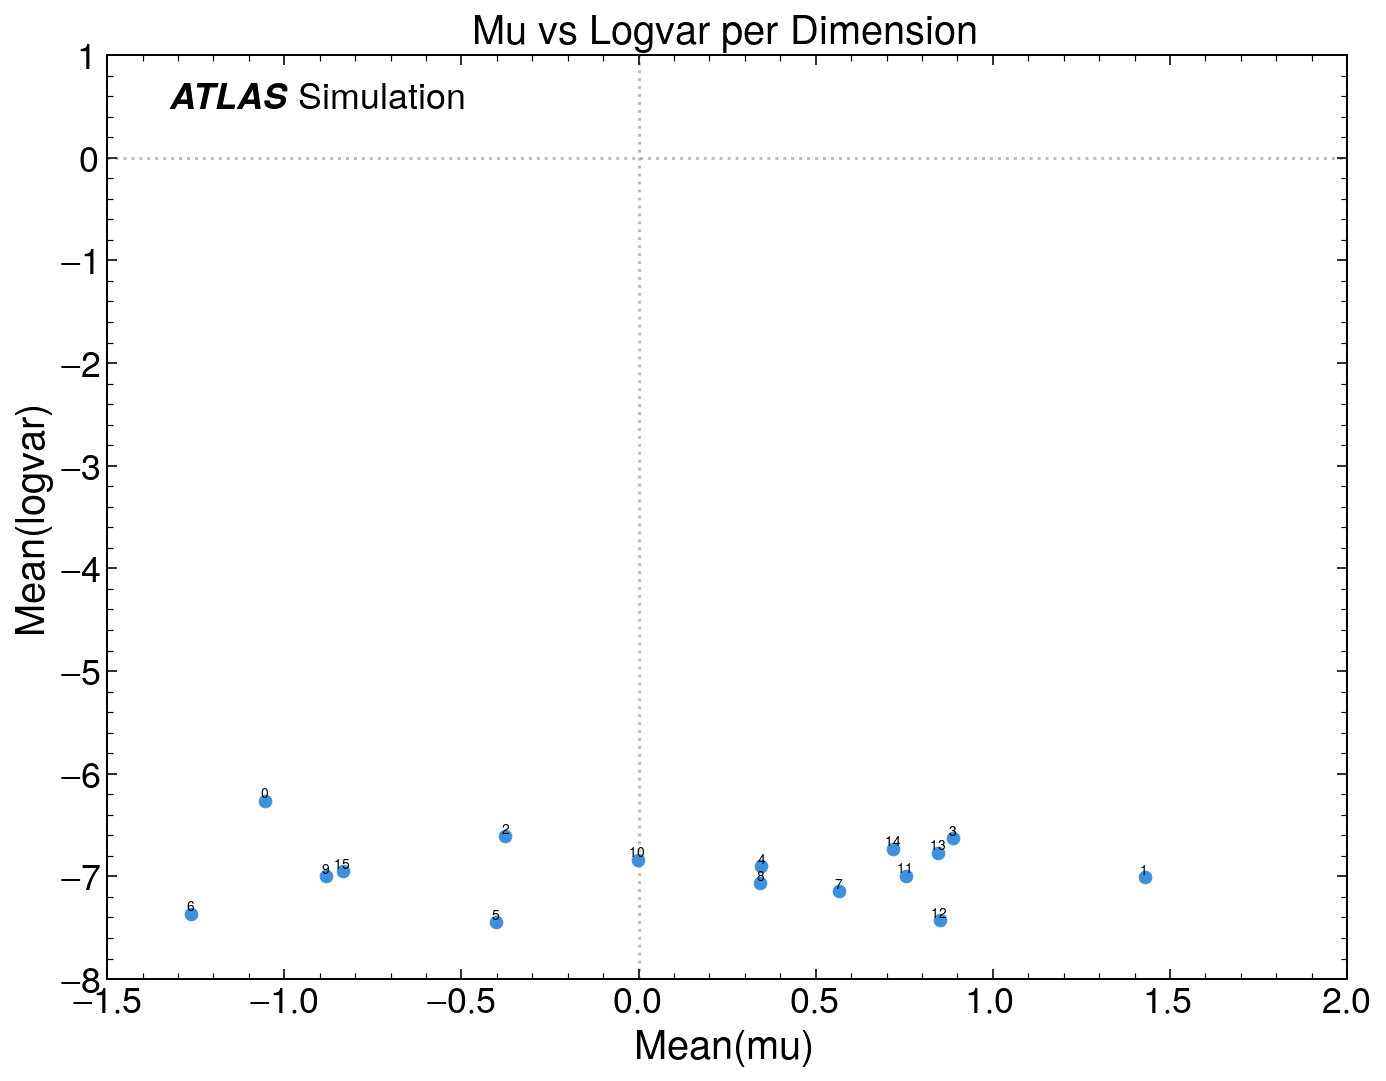

In [25]:
from src.models.plots import plot_mu_vs_logvar

fig = plot_mu_vs_logvar(mu_np, logvar_np)
fig.savefig(plots_dir / "vae_mu_vs_logvar.png")

### KL per Dimension

Mean KL divergence per latent dimension. Identifies which dimensions encode the most information.

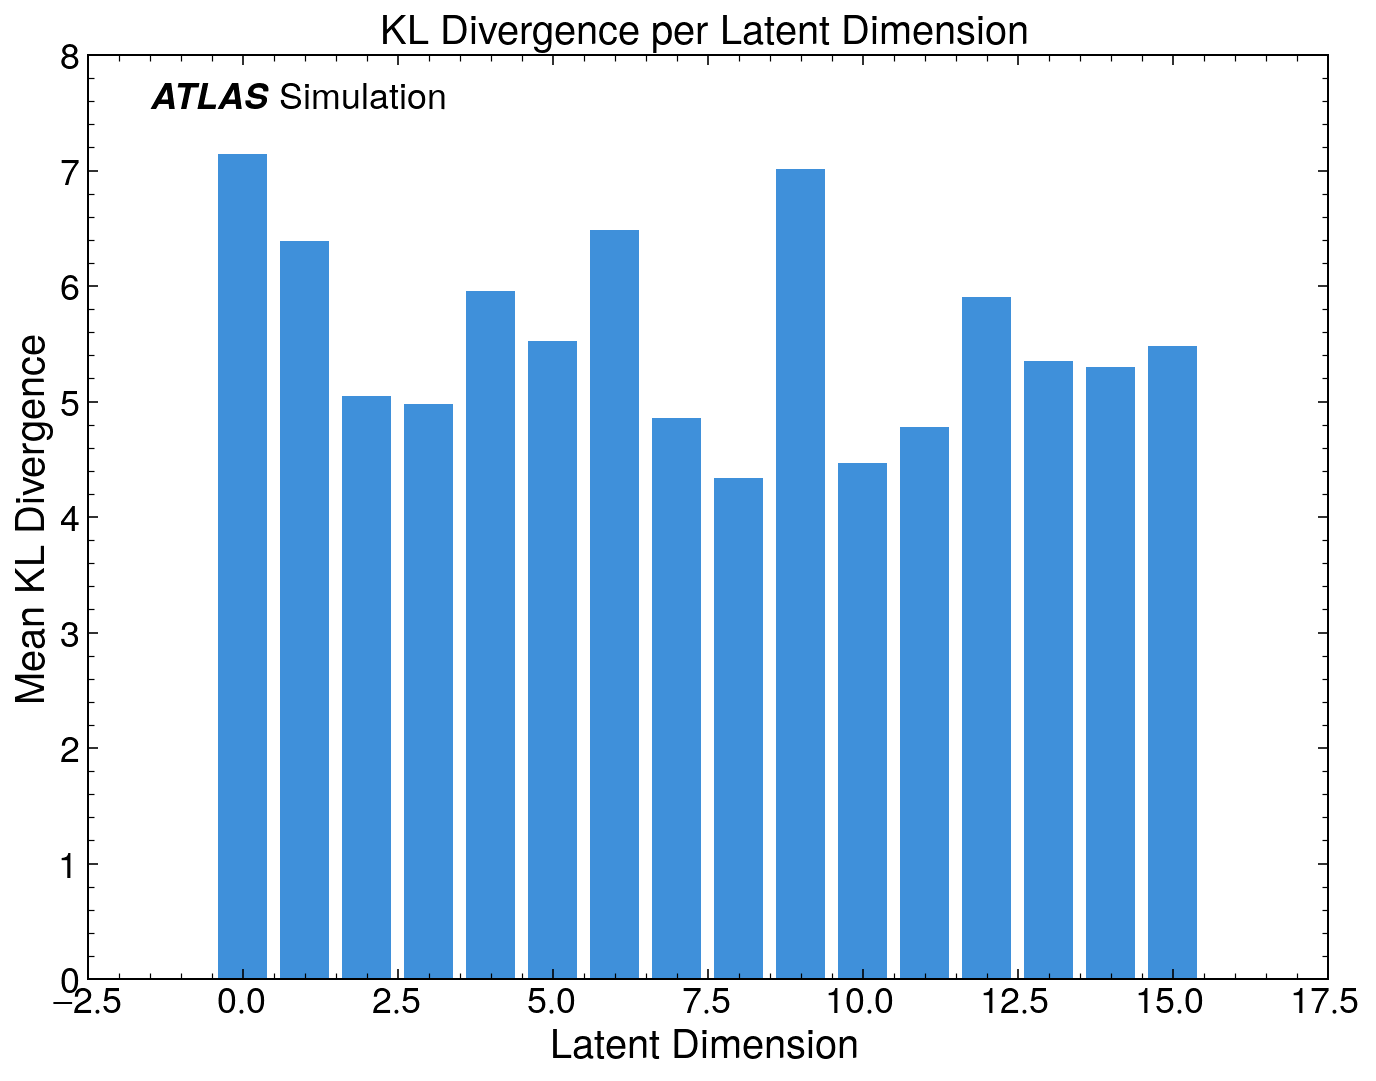

In [26]:
from src.models.plots import plot_kl_per_dimension

kl_per_dim = -0.5 * (1 + logvar_np - mu_np ** 2 - np.exp(logvar_np)).mean(axis=0)
fig = plot_kl_per_dimension(kl_per_dim)
fig.savefig(plots_dir / "vae_kl_per_dim.png")

### Latent Mean Histograms

Per-dimension histograms of the latent mean `mu`.

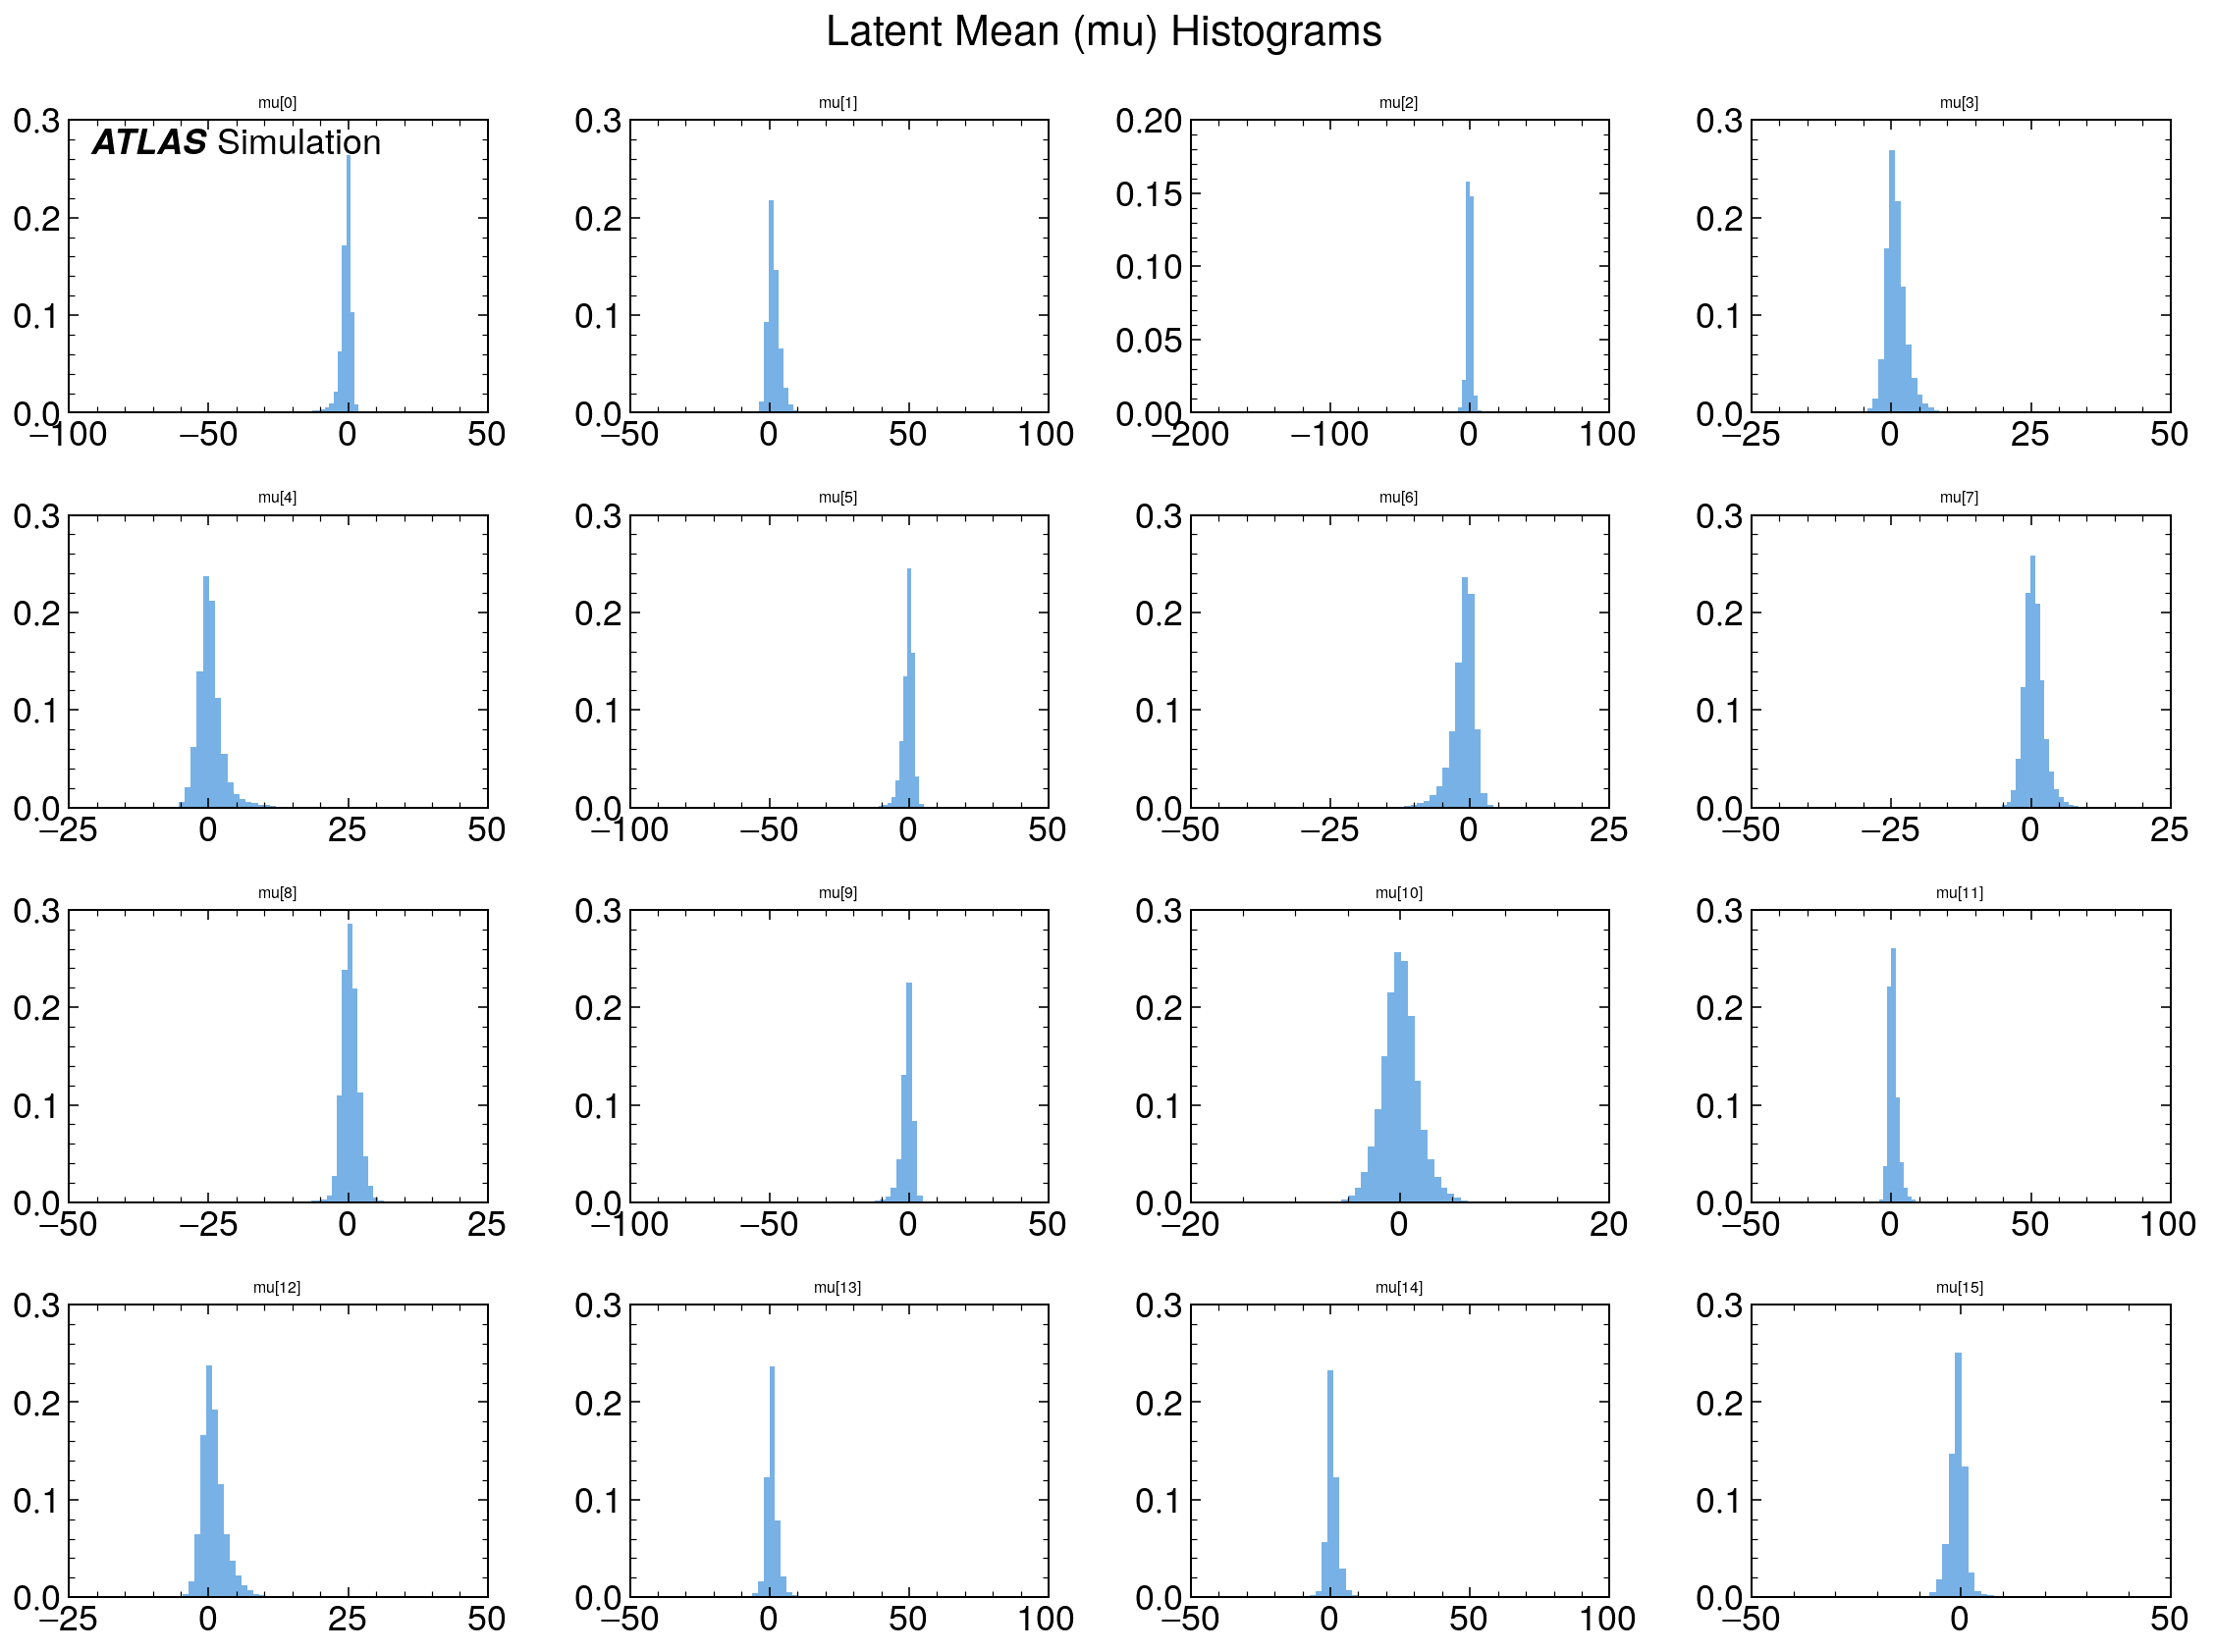

In [27]:
from src.models.plots import plot_latent_mean_histograms

fig = plot_latent_mean_histograms(mu_np)
fig.savefig(plots_dir / "vae_mu_histograms.png")

### Log-Variance Histograms

Per-dimension histograms of `logvar`.

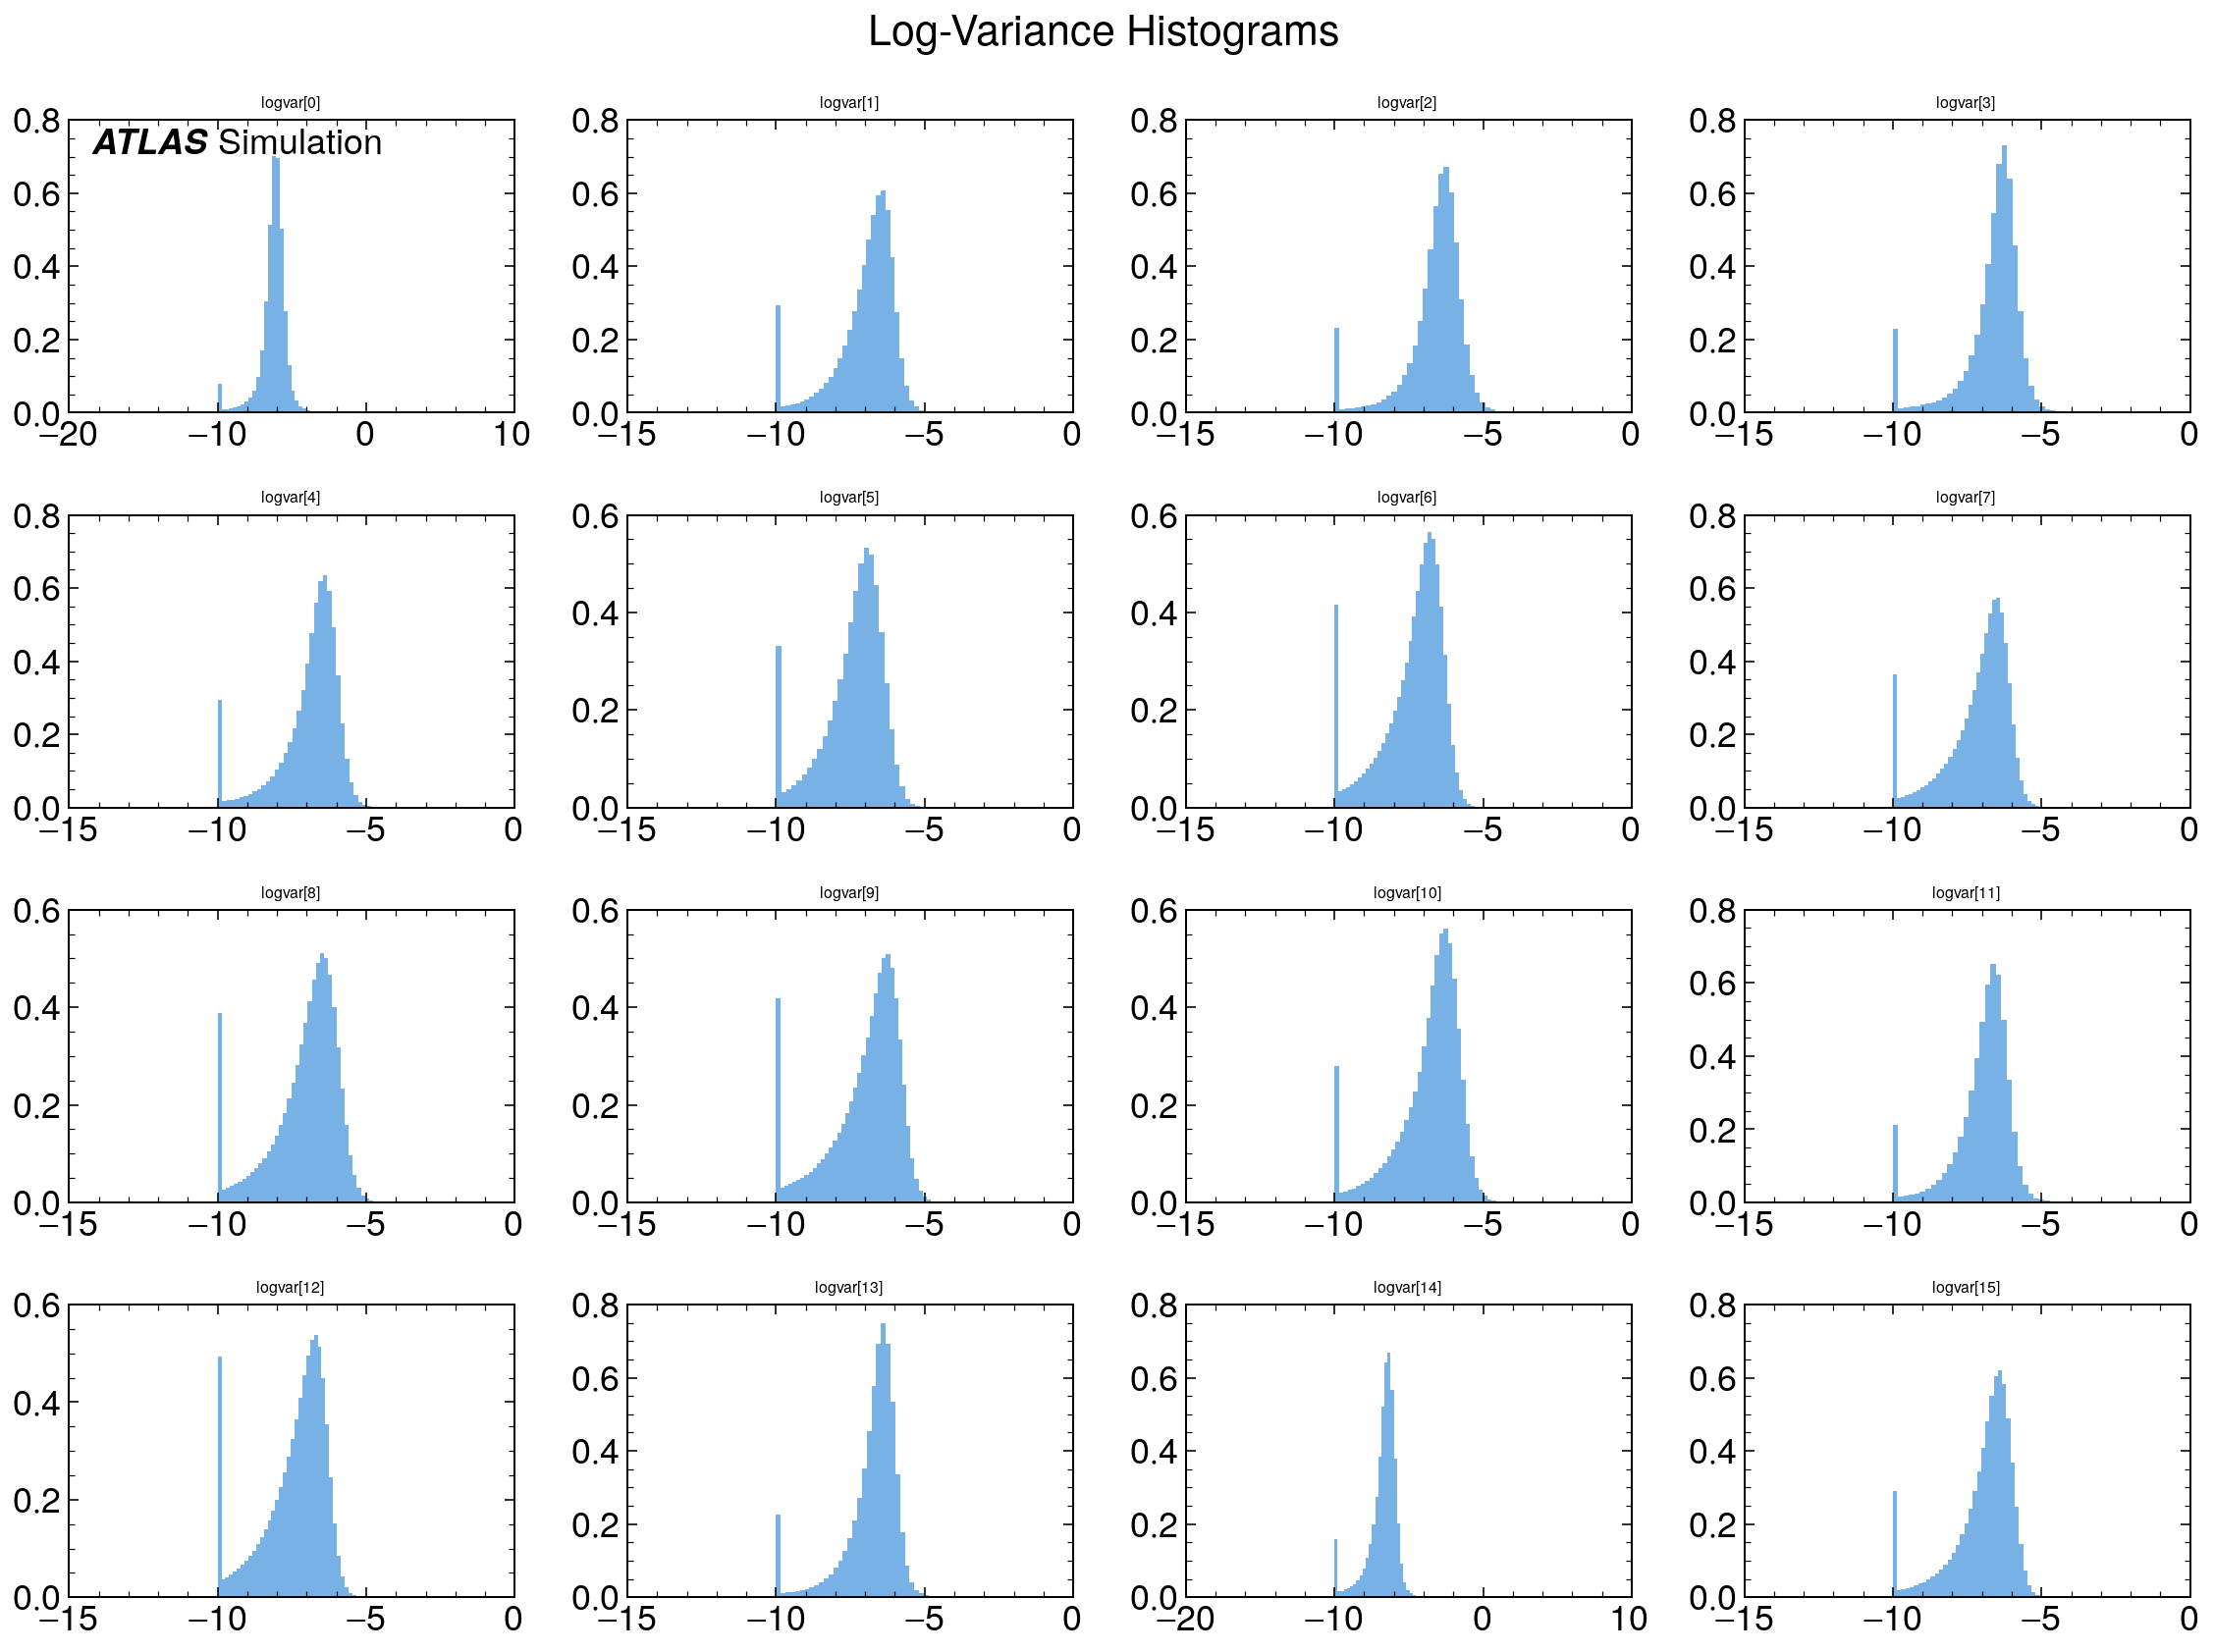

In [28]:
from src.models.plots import plot_logvar_histograms

fig = plot_logvar_histograms(logvar_np)
fig.savefig(plots_dir / "vae_logvar_histograms.png")

### Latent Dimension Histograms

Sampled latent vectors coloured by background vs signal.

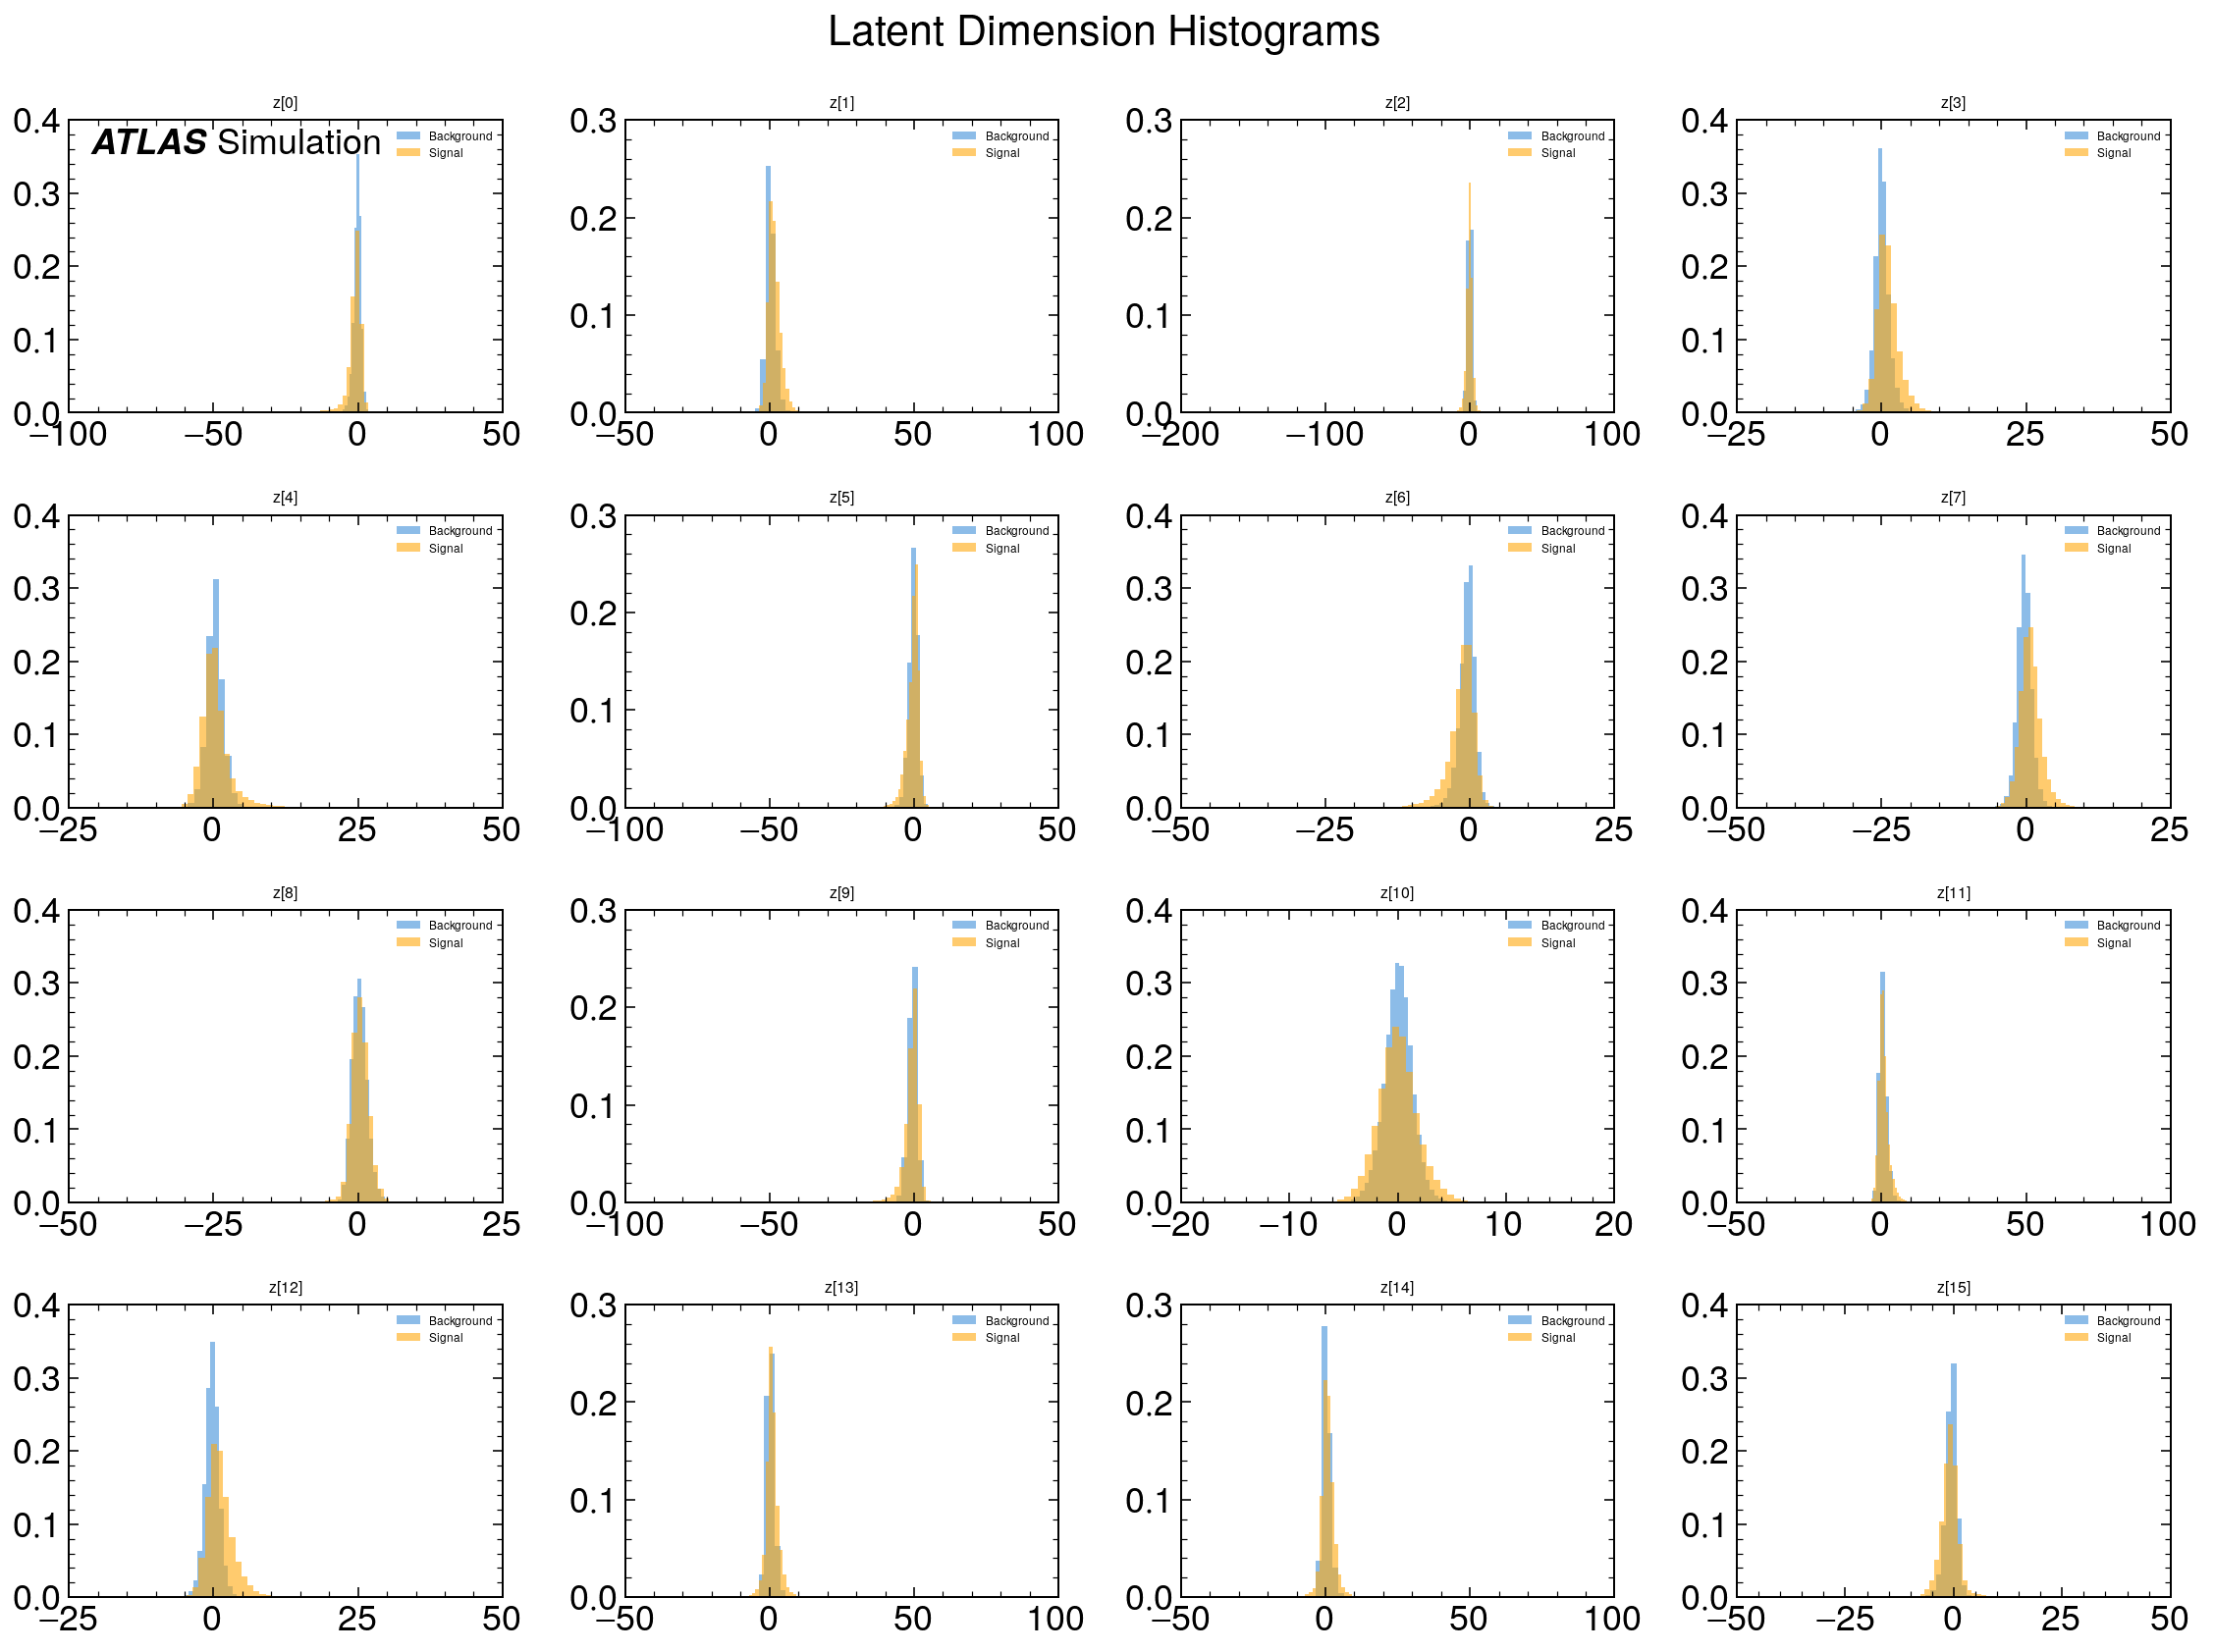

In [29]:
from src.models.plots import plot_latent_histograms

fig = plot_latent_histograms(mu_np, labels=dm.predict_labels)
fig.savefig(plots_dir / "vae_latent_histograms.png")

## Scores DataFrame

Building and saving the tidy scores DataFrame for downstream evaluation.

In [30]:
scores_df = build_scores_frame(scores, dm.predict_labels, dm.predict_origins)
scores_path = dataframes_dir / "vae_scores.parquet"
scores_df.to_parquet(scores_path)
print(f"Saved scores: {scores_path}")
scores_df.head()

Saved scores: /home/islazyk/tau-anomaly-detection/data/processed/ML/25.2.28/Run2/Preselection/1_tau/dataframes/vae_scores.parquet


,anomaly_score,sample_type,eventOrigin
0,0.084735,background,ztautau
1,0.038227,background,diboson
2,0.045065,background,wtaunu
3,0.136089,background,diboson
4,0.580893,background,wtaunu


### Finish WandB

Closing the WandB run.

In [31]:
import wandb

if wandb.run is not None:
    wandb.finish()